<a href="https://colab.research.google.com/github/christinatras/AAI2026/blob/dev/Ad_Optimization_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ad Optimization Agent

## Summary Metrics

,metric,value
0,Total Conversions,"34,066"
1,Total Revenue,"$6,036,011.49"
2,Avg CPA,$39.45
3,ROAS,4.49x
4,Days Simulated,30
5,Conversion Delta % vs Baseline,-2.30%
6,Revenue Delta % vs Baseline,-1.07%
7,CPA Improvement % vs Baseline,-2.35%


## Channel Performance Summary

,channel,spend,conversions,CPA,avg_allocation_pct
0,Search,255875.17,6074,42.13,19.68
1,Social,727669.18,14265,51.01,51.98
2,Display,360376.73,13727,26.25,30.03


## Daily Decision Timeline

,day,date,decision_type,top_channel,agent_conversions,baseline_conversions,agent_cpa,search_alloc,social_alloc,display_alloc
0,1,2024-01-05,init,-,718,718,69.6379,0.3333,0.3333,0.3333
1,2,2024-01-06,exploit,Social,512,512,75.3581,0.2883,0.4833,0.2283
2,3,2024-01-07,exploit,Social,1395,1512,35.8423,0.1833,0.6333,0.1833
3,4,2024-01-08,exploit,Display,1362,1625,36.7107,0.1250,0.6083,0.2667
4,5,2024-01-09,explore,Display,499,738,39.3927,0.0998,0.6069,0.2934
5,6,2024-01-10,explore,Display,1698,1345,20.7511,0.0997,0.6050,0.2953
6,7,2024-01-11,exploit,Search,879,891,56.8828,0.2497,0.5600,0.1903
7,8,2024-01-12,explore,Search,1500,1369,27.1381,0.2541,0.5600,0.1859
8,9,2024-01-13,exploit,Social,706,892,60.2600,0.1491,0.7100,0.1409
9,10,2024-01-14,exploit,Display,486,486,91.0763,0.1147,0.6953,0.1900


## Agent Log

,day,date,reason
0,1,2024-01-05,Day 1 initialization: equal 33.3% split across...
1,2,2024-01-06,Exploit: Social leads with CVR=5.6% and CPA=$2...
2,3,2024-01-07,Exploit: Social leads with CVR=5.4% and CPA=$2...
3,4,2024-01-08,Exploit: Display leads with CVR=7.1% and CPA=$...
4,5,2024-01-09,Exploring: boosted Display by about 3% to prob...
5,6,2024-01-10,Exploring: boosted Display by about 0% to prob...
6,7,2024-01-11,Exploit: Search leads with CVR=3.9% and CPA=$8...
7,8,2024-01-12,Exploring: boosted Search by about 0% to probe...
8,9,2024-01-13,Exploit: Social leads with CVR=6.2% and CPA=$2...
9,10,2024-01-14,Exploit: Display leads with CVR=3.9% and CPA=$...


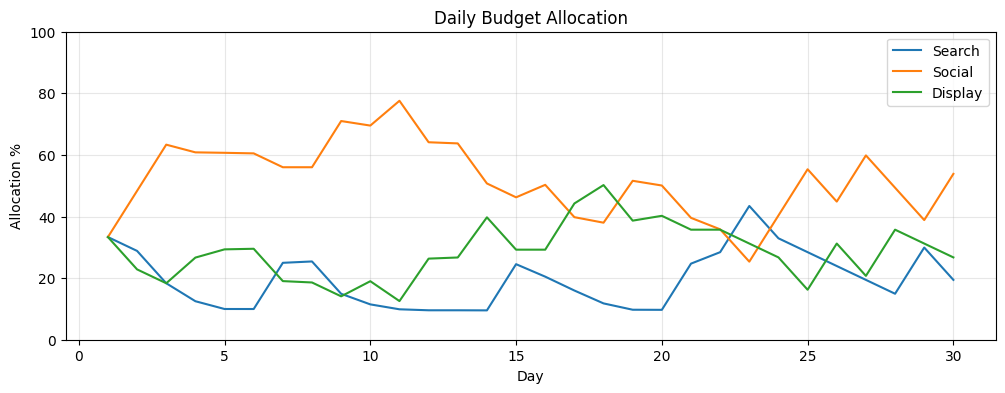

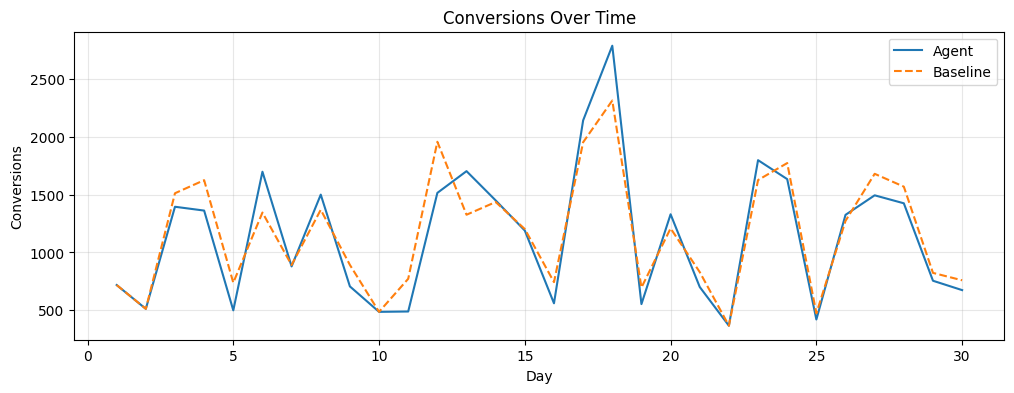

# Ad Optimization Agent (Python / Colab)

Interactive Python conversion of the uploaded HTML/JS simulation.

In [ ]:
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Optional

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output, Markdown
import ipywidgets as widgets

#Raw data collected from the Kaggle file, sorted

RAW_DATA = [{"date":"2024-01-05","channel":"Display","impressions":58074,"clicks":3366,"ad_spend":2476.22,"conversions":57,"revenue":10016.46,"CTR":0.058,"CVR":0.0169,"CPA":43.44},{"date":"2024-01-05","channel":"Search","impressions":196692,"clicks":6264,"ad_spend":15668.95,"conversions":310,"revenue":64727.9,"CTR":0.0318,"CVR":0.0495,"CPA":50.54},{"date":"2024-01-05","channel":"Social","impressions":238928,"clicks":4323,"ad_spend":5064.01,"conversions":137,"revenue":16223.53,"CTR":0.0181,"CVR":0.0317,"CPA":36.96},{"date":"2024-01-06","channel":"Search","impressions":139158,"clicks":3061,"ad_spend":3887.47,"conversions":118,"revenue":15835.46,"CTR":0.022,"CVR":0.0385,"CPA":32.94},{"date":"2024-01-06","channel":"Social","impressions":149444,"clicks":2451,"ad_spend":2771.19,"conversions":138,"revenue":33237.29,"CTR":0.0164,"CVR":0.0563,"CPA":20.08},{"date":"2024-01-07","channel":"Display","impressions":166711,"clicks":13670,"ad_spend":20505.0,"conversions":592,"revenue":43676.76,"CTR":0.082,"CVR":0.0433,"CPA":34.64},{"date":"2024-01-07","channel":"Search","impressions":238097,"clicks":9087,"ad_spend":21959.64,"conversions":340,"revenue":49123.74,"CTR":0.0382,"CVR":0.0374,"CPA":64.59},{"date":"2024-01-07","channel":"Social","impressions":375619,"clicks":9116,"ad_spend":10644.45,"conversions":494,"revenue":110160.57,"CTR":0.0243,"CVR":0.0542,"CPA":21.55},{"date":"2024-01-08","channel":"Display","impressions":162795,"clicks":8107,"ad_spend":7782.72,"conversions":575,"revenue":86383.64,"CTR":0.0498,"CVR":0.0709,"CPA":13.54},{"date":"2024-01-08","channel":"Search","impressions":195843,"clicks":8509,"ad_spend":14230.74,"conversions":134,"revenue":10672.41,"CTR":0.0434,"CVR":0.0157,"CPA":106.2},{"date":"2024-01-08","channel":"Social","impressions":127775,"clicks":3871,"ad_spend":2941.96,"conversions":159,"revenue":28717.22,"CTR":0.0303,"CVR":0.0411,"CPA":18.5},{"date":"2024-01-09","channel":"Display","impressions":96310,"clicks":6905,"ad_spend":8838.4,"conversions":247,"revenue":8632.99,"CTR":0.0717,"CVR":0.0358,"CPA":35.78},{"date":"2024-01-09","channel":"Search","impressions":162054,"clicks":5391,"ad_spend":7601.31,"conversions":136,"revenue":28139.22,"CTR":0.0333,"CVR":0.0252,"CPA":55.89},{"date":"2024-01-10","channel":"Search","impressions":301299,"clicks":14009,"ad_spend":42769.86,"conversions":580,"revenue":139104.1,"CTR":0.0465,"CVR":0.0414,"CPA":73.74},{"date":"2024-01-10","channel":"Social","impressions":362879,"clicks":11583,"ad_spend":12141.53,"conversions":815,"revenue":129012.16,"CTR":0.0319,"CVR":0.0704,"CPA":14.9},{"date":"2024-01-11","channel":"Display","impressions":254732,"clicks":9877,"ad_spend":12761.48,"conversions":259,"revenue":56410.78,"CTR":0.0388,"CVR":0.0262,"CPA":49.27},{"date":"2024-01-11","channel":"Search","impressions":48351,"clicks":2156,"ad_spend":6812.96,"conversions":83,"revenue":7504.87,"CTR":0.0446,"CVR":0.0385,"CPA":82.08},{"date":"2024-01-11","channel":"Social","impressions":297970,"clicks":8274,"ad_spend":11503.86,"conversions":267,"revenue":19794.53,"CTR":0.0278,"CVR":0.0323,"CPA":43.09},{"date":"2024-01-12","channel":"Search","impressions":124273,"clicks":3603,"ad_spend":5584.65,"conversions":167,"revenue":20460.25,"CTR":0.029,"CVR":0.0464,"CPA":33.44},{"date":"2024-01-12","channel":"Social","impressions":525594,"clicks":12739,"ad_spend":9384.14,"conversions":583,"revenue":99880.31,"CTR":0.0242,"CVR":0.0458,"CPA":16.1},{"date":"2024-01-13","channel":"Display","impressions":83871,"clicks":6382,"ad_spend":6701.1,"conversions":196,"revenue":31406.57,"CTR":0.0761,"CVR":0.0307,"CPA":34.19},{"date":"2024-01-13","channel":"Social","impressions":233270,"clicks":4067,"ad_spend":5447.42,"conversions":250,"revenue":55490.36,"CTR":0.0174,"CVR":0.0615,"CPA":21.79},{"date":"2024-01-14","channel":"Display","impressions":85428,"clicks":5134,"ad_spend":4415.24,"conversions":202,"revenue":37603.74,"CTR":0.0601,"CVR":0.0393,"CPA":21.86},{"date":"2024-01-14","channel":"Social","impressions":171020,"clicks":2616,"ad_spend":1151.04,"conversions":41,"revenue":9636.88,"CTR":0.0153,"CVR":0.0157,"CPA":28.07},{"date":"2024-01-15","channel":"Search","impressions":252172,"clicks":11039,"ad_spend":18390.59,"conversions":444,"revenue":62149.61,"CTR":0.0438,"CVR":0.0402,"CPA":41.42},{"date":"2024-01-15","channel":"Social","impressions":113269,"clicks":3182,"ad_spend":4868.46,"conversions":185,"revenue":53909.5,"CTR":0.0281,"CVR":0.0581,"CPA":26.32},{"date":"2024-01-16","channel":"Display","impressions":207509,"clicks":11237,"ad_spend":7153.8,"conversions":475,"revenue":66053.72,"CTR":0.0542,"CVR":0.0423,"CPA":15.06},{"date":"2024-01-16","channel":"Search","impressions":399757,"clicks":9956,"ad_spend":13808.29,"conversions":425,"revenue":37194.83,"CTR":0.0249,"CVR":0.0427,"CPA":32.49},{"date":"2024-01-16","channel":"Social","impressions":311314,"clicks":7974,"ad_spend":5616.68,"conversions":247,"revenue":42262.82,"CTR":0.0256,"CVR":0.031,"CPA":22.74},{"date":"2024-01-17","channel":"Display","impressions":363083,"clicks":23383,"ad_spend":32074.61,"conversions":1102,"revenue":145203.76,"CTR":0.0644,"CVR":0.0471,"CPA":29.11},{"date":"2024-01-17","channel":"Search","impressions":149661,"clicks":5064,"ad_spend":11296.29,"conversions":82,"revenue":19302.47,"CTR":0.0338,"CVR":0.0162,"CPA":137.76},{"date":"2024-01-17","channel":"Social","impressions":539054,"clicks":12859,"ad_spend":16183.58,"conversions":614,"revenue":116389.58,"CTR":0.0239,"CVR":0.0477,"CPA":26.36},{"date":"2024-01-18","channel":"Display","impressions":341436,"clicks":12020,"ad_spend":14906.16,"conversions":737,"revenue":189271.31,"CTR":0.0352,"CVR":0.0613,"CPA":20.23},{"date":"2024-01-18","channel":"Search","impressions":132040,"clicks":4963,"ad_spend":14562.3,"conversions":305,"revenue":54354.99,"CTR":0.0376,"CVR":0.0615,"CPA":47.75},{"date":"2024-01-18","channel":"Social","impressions":241820,"clicks":6506,"ad_spend":11638.56,"conversions":184,"revenue":15220.46,"CTR":0.0269,"CVR":0.0283,"CPA":63.25},{"date":"2024-01-19","channel":"Display","impressions":179561,"clicks":8600,"ad_spend":12384.0,"conversions":212,"revenue":34386.07,"CTR":0.0479,"CVR":0.0247,"CPA":58.42},{"date":"2024-01-19","channel":"Search","impressions":137839,"clicks":5332,"ad_spend":9283.32,"conversions":286,"revenue":27937.51,"CTR":0.0387,"CVR":0.0536,"CPA":32.46},{"date":"2024-01-19","channel":"Social","impressions":216759,"clicks":8321,"ad_spend":15663.3,"conversions":380,"revenue":70127.91,"CTR":0.0384,"CVR":0.0457,"CPA":41.22},{"date":"2024-01-20","channel":"Display","impressions":182325,"clicks":8661,"ad_spend":8116.86,"conversions":148,"revenue":17943.62,"CTR":0.0475,"CVR":0.0171,"CPA":54.84},{"date":"2024-01-20","channel":"Search","impressions":304009,"clicks":14473,"ad_spend":33694.9,"conversions":806,"revenue":199701.36,"CTR":0.0476,"CVR":0.0557,"CPA":41.81},{"date":"2024-01-20","channel":"Social","impressions":147897,"clicks":2144,"ad_spend":4159.36,"conversions":24,"revenue":3826.61,"CTR":0.0145,"CVR":0.0112,"CPA":173.31},{"date":"2024-01-21","channel":"Display","impressions":372739,"clicks":20993,"ad_spend":20507.83,"conversions":1406,"revenue":252710.44,"CTR":0.0563,"CVR":0.067,"CPA":14.59},{"date":"2024-01-21","channel":"Search","impressions":400590,"clicks":18267,"ad_spend":47577.76,"conversions":1010,"revenue":88268.53,"CTR":0.0456,"CVR":0.0553,"CPA":47.11},{"date":"2024-01-21","channel":"Social","impressions":161646,"clicks":5253,"ad_spend":5253.0,"conversions":228,"revenue":43732.39,"CTR":0.0325,"CVR":0.0434,"CPA":23.04},{"date":"2024-01-22","channel":"Display","impressions":261076,"clicks":13991,"ad_spend":14484.31,"conversions":1078,"revenue":115713.25,"CTR":0.0536,"CVR":0.077,"CPA":13.44},{"date":"2024-01-22","channel":"Search","impressions":267417,"clicks":9799,"ad_spend":28253.62,"conversions":404,"revenue":51035.96,"CTR":0.0366,"CVR":0.0412,"CPA":69.93},{"date":"2024-01-22","channel":"Social","impressions":278389,"clicks":7462,"ad_spend":5812.42,"conversions":418,"revenue":91948.88,"CTR":0.0268,"CVR":0.056,"CPA":13.91},{"date":"2024-01-23","channel":"Search","impressions":65927,"clicks":2370,"ad_spend":4531.32,"conversions":154,"revenue":20156.55,"CTR":0.0359,"CVR":0.065,"CPA":29.42},{"date":"2024-01-23","channel":"Social","impressions":90716,"clicks":3002,"ad_spend":4412.94,"conversions":194,"revenue":39560.54,"CTR":0.0331,"CVR":0.0646,"CPA":22.75},{"date":"2024-01-24","channel":"Display","impressions":187229,"clicks":7454,"ad_spend":8800.83,"conversions":386,"revenue":104740.0,"CTR":0.0398,"CVR":0.0518,"CPA":22.8},{"date":"2024-01-24","channel":"Search","impressions":31325,"clicks":858,"ad_spend":1818.96,"conversions":43,"revenue":2004.67,"CTR":0.0274,"CVR":0.0501,"CPA":42.3},{"date":"2024-01-24","channel":"Social","impressions":191478,"clicks":6414,"ad_spend":10069.98,"conversions":236,"revenue":56534.15,"CTR":0.0335,"CVR":0.0368,"CPA":42.67},{"date":"2024-01-25","channel":"Display","impressions":89126,"clicks":3964,"ad_spend":6885.56,"conversions":148,"revenue":10535.91,"CTR":0.0445,"CVR":0.0373,"CPA":46.52},{"date":"2024-01-25","channel":"Search","impressions":449663,"clicks":12813,"ad_spend":19020.63,"conversions":571,"revenue":116643.43,"CTR":0.0285,"CVR":0.0446,"CPA":33.31},{"date":"2024-01-25","channel":"Social","impressions":27499,"clicks":728,"ad_spend":778.96,"conversions":17,"revenue":3860.75,"CTR":0.0265,"CVR":0.0234,"CPA":45.82},{"date":"2024-01-26","channel":"Display","impressions":34118,"clicks":1470,"ad_spend":1249.5,"conversions":55,"revenue":3037.11,"CTR":0.0431,"CVR":0.0374,"CPA":22.72},{"date":"2024-01-26","channel":"Social","impressions":177593,"clicks":1811,"ad_spend":1430.69,"conversions":128,"revenue":17092.48,"CTR":0.0102,"CVR":0.0707,"CPA":11.18},{"date":"2024-01-27","channel":"Display","impressions":266087,"clicks":13097,"ad_spend":10839.19,"conversions":393,"revenue":50163.99,"CTR":0.0492,"CVR":0.03,"CPA":27.58},{"date":"2024-01-27","channel":"Search","impressions":308977,"clicks":12461,"ad_spend":18023.21,"conversions":907,"revenue":180906.82,"CTR":0.0403,"CVR":0.0728,"CPA":19.87},{"date":"2024-01-27","channel":"Social","impressions":335138,"clicks":9134,"ad_spend":12316.62,"conversions":135,"revenue":16042.9,"CTR":0.0273,"CVR":0.0148,"CPA":91.23},{"date":"2024-01-28","channel":"Display","impressions":138689,"clicks":10387,"ad_spend":10530.74,"conversions":429,"revenue":94636.92,"CTR":0.0749,"CVR":0.0413,"CPA":24.55},{"date":"2024-01-28","channel":"Search","impressions":231983,"clicks":7269,"ad_spend":12247.79,"conversions":256,"revenue":65115.1,"CTR":0.0313,"CVR":0.0352,"CPA":47.84},{"date":"2024-01-28","channel":"Social","impressions":207844,"clicks":5782,"ad_spend":5424.64,"conversions":373,"revenue":69138.53,"CTR":0.0278,"CVR":0.0645,"CPA":14.54},{"date":"2024-01-29","channel":"Search","impressions":267714,"clicks":10614,"ad_spend":14946.38,"conversions":324,"revenue":75451.81,"CTR":0.0396,"CVR":0.0305,"CPA":46.13},{"date":"2024-01-29","channel":"Social","impressions":133981,"clicks":1985,"ad_spend":1689.3,"conversions":56,"revenue":12792.52,"CTR":0.0148,"CVR":0.0282,"CPA":30.17},{"date":"2024-01-30","channel":"Display","impressions":48147,"clicks":3562,"ad_spend":1496.04,"conversions":163,"revenue":41382.29,"CTR":0.074,"CVR":0.0458,"CPA":9.18},{"date":"2024-01-30","channel":"Search","impressions":320643,"clicks":8030,"ad_spend":22903.64,"conversions":507,"revenue":53391.99,"CTR":0.025,"CVR":0.0631,"CPA":45.17},{"date":"2024-01-30","channel":"Social","impressions":223931,"clicks":7538,"ad_spend":10588.28,"conversions":367,"revenue":50929.89,"CTR":0.0337,"CVR":0.0487,"CPA":28.85},{"date":"2024-01-31","channel":"Display","impressions":302458,"clicks":17931,"ad_spend":15505.53,"conversions":732,"revenue":127718.12,"CTR":0.0593,"CVR":0.0408,"CPA":21.18},{"date":"2024-01-31","channel":"Search","impressions":64739,"clicks":1599,"ad_spend":5212.74,"conversions":109,"revenue":22723.24,"CTR":0.0247,"CVR":0.0682,"CPA":47.82},{"date":"2024-01-31","channel":"Social","impressions":153157,"clicks":5498,"ad_spend":9896.4,"conversions":401,"revenue":90694.52,"CTR":0.0359,"CVR":0.0729,"CPA":24.68},{"date":"2024-02-01","channel":"Display","impressions":279792,"clicks":22587,"ad_spend":16008.28,"conversions":992,"revenue":244653.35,"CTR":0.0807,"CVR":0.0439,"CPA":16.14},{"date":"2024-02-01","channel":"Search","impressions":122471,"clicks":7281,"ad_spend":11560.09,"conversions":273,"revenue":49662.97,"CTR":0.0595,"CVR":0.0375,"CPA":42.34},{"date":"2024-02-01","channel":"Social","impressions":129470,"clicks":2755,"ad_spend":3205.59,"conversions":71,"revenue":11351.95,"CTR":0.0213,"CVR":0.0258,"CPA":45.15},{"date":"2024-02-02","channel":"Display","impressions":308899,"clicks":23961,"ad_spend":35211.33,"conversions":856,"revenue":202258.62,"CTR":0.0776,"CVR":0.0357,"CPA":41.13},{"date":"2024-02-02","channel":"Search","impressions":259798,"clicks":12374,"ad_spend":27852.12,"conversions":698,"revenue":121184.55,"CTR":0.0476,"CVR":0.0564,"CPA":39.9},{"date":"2024-02-03","channel":"Display","impressions":173270,"clicks":10217,"ad_spend":16847.34,"conversions":434,"revenue":92580.68,"CTR":0.059,"CVR":0.0425,"CPA":38.82},{"date":"2024-02-03","channel":"Social","impressions":124366,"clicks":3213,"ad_spend":5319.27,"conversions":165,"revenue":35702.37,"CTR":0.0258,"CVR":0.0514,"CPA":32.24},{"date":"2024-02-04","channel":"Search","impressions":304488,"clicks":10143,"ad_spend":19672.08,"conversions":443,"revenue":48314.91,"CTR":0.0333,"CVR":0.0437,"CPA":44.41},{"date":"2024-02-04","channel":"Social","impressions":206669,"clicks":4604,"ad_spend":4758.77,"conversions":231,"revenue":58373.12,"CTR":0.0223,"CVR":0.0502,"CPA":20.6},{"date":"2024-02-05","channel":"Display","impressions":382445,"clicks":17127,"ad_spend":11701.68,"conversions":585,"revenue":77467.98,"CTR":0.0448,"CVR":0.0342,"CPA":20.0},{"date":"2024-02-05","channel":"Search","impressions":12045,"clicks":255,"ad_spend":515.1,"conversions":4,"revenue":161.02,"CTR":0.0212,"CVR":0.0157,"CPA":128.78},{"date":"2024-02-05","channel":"Social","impressions":145510,"clicks":5805,"ad_spend":6037.2,"conversions":166,"revenue":30713.7,"CTR":0.0399,"CVR":0.0286,"CPA":36.37},{"date":"2024-02-06","channel":"Display","impressions":102184,"clicks":6028,"ad_spend":4954.12,"conversions":346,"revenue":67494.43,"CTR":0.059,"CVR":0.0574,"CPA":14.32},{"date":"2024-02-06","channel":"Search","impressions":307203,"clicks":11302,"ad_spend":30912.41,"conversions":621,"revenue":119433.7,"CTR":0.0368,"CVR":0.0549,"CPA":49.78},{"date":"2024-02-06","channel":"Social","impressions":335174,"clicks":6486,"ad_spend":7584.24,"conversions":276,"revenue":32522.88,"CTR":0.0194,"CVR":0.0426,"CPA":27.48},{"date":"2024-02-07","channel":"Display","impressions":211835,"clicks":11900,"ad_spend":5376.8,"conversions":427,"revenue":41333.68,"CTR":0.0562,"CVR":0.0359,"CPA":12.59},{"date":"2024-02-07","channel":"Search","impressions":260280,"clicks":13750,"ad_spend":27733.36,"conversions":657,"revenue":92119.23,"CTR":0.0528,"CVR":0.0478,"CPA":42.21},{"date":"2024-02-07","channel":"Social","impressions":170448,"clicks":4945,"ad_spend":8114.05,"conversions":191,"revenue":32937.13,"CTR":0.029,"CVR":0.0386,"CPA":42.48},{"date":"2024-02-08","channel":"Display","impressions":260805,"clicks":15741,"ad_spend":13275.92,"conversions":432,"revenue":40791.36,"CTR":0.0604,"CVR":0.0274,"CPA":30.73},{"date":"2024-02-08","channel":"Search","impressions":10574,"clicks":389,"ad_spend":1007.51,"conversions":6,"revenue":908.68,"CTR":0.0368,"CVR":0.0154,"CPA":167.92},{"date":"2024-02-08","channel":"Social","impressions":151480,"clicks":2514,"ad_spend":5178.84,"conversions":72,"revenue":4076.45,"CTR":0.0166,"CVR":0.0286,"CPA":71.93},{"date":"2024-02-09","channel":"Social","impressions":170413,"clicks":3936,"ad_spend":2794.56,"conversions":63,"revenue":12671.79,"CTR":0.0231,"CVR":0.016,"CPA":44.36},{"date":"2024-02-10","channel":"Display","impressions":116709,"clicks":6640,"ad_spend":13080.8,"conversions":304,"revenue":83458.18,"CTR":0.0569,"CVR":0.0458,"CPA":43.03},{"date":"2024-02-10","channel":"Search","impressions":191915,"clicks":5356,"ad_spend":8804.56,"conversions":131,"revenue":27549.48,"CTR":0.0279,"CVR":0.0245,"CPA":67.21},{"date":"2024-02-10","channel":"Social","impressions":141313,"clicks":4762,"ad_spend":5000.1,"conversions":207,"revenue":26737.15,"CTR":0.0337,"CVR":0.0435,"CPA":24.16},{"date":"2024-02-11","channel":"Display","impressions":235092,"clicks":12757,"ad_spend":7872.36,"conversions":714,"revenue":190302.46,"CTR":0.0543,"CVR":0.056,"CPA":11.03},{"date":"2024-02-11","channel":"Search","impressions":166172,"clicks":6341,"ad_spend":13535.23,"conversions":336,"revenue":85021.93,"CTR":0.0382,"CVR":0.053,"CPA":40.28},{"date":"2024-02-11","channel":"Social","impressions":92986,"clicks":2082,"ad_spend":3601.86,"conversions":108,"revenue":6838.55,"CTR":0.0224,"CVR":0.0519,"CPA":33.35},{"date":"2024-02-12","channel":"Display","impressions":115782,"clicks":5393,"ad_spend":3463.57,"conversions":204,"revenue":25795.55,"CTR":0.0466,"CVR":0.0378,"CPA":16.98},{"date":"2024-02-13","channel":"Search","impressions":390907,"clicks":18793,"ad_spend":39601.7,"conversions":737,"revenue":118833.65,"CTR":0.0481,"CVR":0.0392,"CPA":53.73},{"date":"2024-02-13","channel":"Social","impressions":57299,"clicks":1186,"ad_spend":1601.1,"conversions":25,"revenue":5383.27,"CTR":0.0207,"CVR":0.0211,"CPA":64.04},{"date":"2024-02-14","channel":"Display","impressions":79553,"clicks":2712,"ad_spend":840.72,"conversions":170,"revenue":16973.79,"CTR":0.0341,"CVR":0.0627,"CPA":4.95},{"date":"2024-02-14","channel":"Search","impressions":25497,"clicks":1142,"ad_spend":2101.28,"conversions":75,"revenue":18551.01,"CTR":0.0448,"CVR":0.0657,"CPA":28.02},{"date":"2024-02-14","channel":"Social","impressions":83137,"clicks":2045,"ad_spend":2065.45,"conversions":37,"revenue":1798.59,"CTR":0.0246,"CVR":0.0181,"CPA":55.82},{"date":"2024-02-15","channel":"Search","impressions":70589,"clicks":2932,"ad_spend":6489.31,"conversions":122,"revenue":10787.54,"CTR":0.0415,"CVR":0.0416,"CPA":53.19},{"date":"2024-02-15","channel":"Social","impressions":67167,"clicks":1907,"ad_spend":2727.01,"conversions":114,"revenue":20596.75,"CTR":0.0284,"CVR":0.0598,"CPA":23.92},{"date":"2024-02-16","channel":"Display","impressions":141447,"clicks":9873,"ad_spend":13723.47,"conversions":588,"revenue":86774.51,"CTR":0.0698,"CVR":0.0596,"CPA":23.34},{"date":"2024-02-16","channel":"Search","impressions":602745,"clicks":22092,"ad_spend":49953.63,"conversions":1059,"revenue":220347.1,"CTR":0.0367,"CVR":0.0479,"CPA":47.17},{"date":"2024-02-16","channel":"Social","impressions":531844,"clicks":15564,"ad_spend":29984.4,"conversions":941,"revenue":125949.31,"CTR":0.0293,"CVR":0.0605,"CPA":31.86},{"date":"2024-02-17","channel":"Display","impressions":243735,"clicks":17396,"ad_spend":29865.35,"conversions":733,"revenue":86904.4,"CTR":0.0714,"CVR":0.0421,"CPA":40.74},{"date":"2024-02-17","channel":"Search","impressions":518932,"clicks":22916,"ad_spend":53988.93,"conversions":721,"revenue":146760.8,"CTR":0.0442,"CVR":0.0315,"CPA":74.88},{"date":"2024-02-17","channel":"Social","impressions":390217,"clicks":13248,"ad_spend":21405.23,"conversions":274,"revenue":57687.78,"CTR":0.034,"CVR":0.0207,"CPA":78.12},{"date":"2024-02-18","channel":"Display","impressions":367341,"clicks":17813,"ad_spend":15897.69,"conversions":1083,"revenue":153283.64,"CTR":0.0485,"CVR":0.0608,"CPA":14.68},{"date":"2024-02-18","channel":"Search","impressions":208293,"clicks":5724,"ad_spend":8107.88,"conversions":89,"revenue":15379.69,"CTR":0.0275,"CVR":0.0155,"CPA":91.1},{"date":"2024-02-18","channel":"Social","impressions":389870,"clicks":12179,"ad_spend":22475.43,"conversions":779,"revenue":126463.84,"CTR":0.0312,"CVR":0.064,"CPA":28.85},{"date":"2024-02-19","channel":"Search","impressions":391865,"clicks":12936,"ad_spend":24409.08,"conversions":660,"revenue":87866.75,"CTR":0.033,"CVR":0.051,"CPA":36.98},{"date":"2024-02-20","channel":"Search","impressions":399647,"clicks":15334,"ad_spend":36040.22,"conversions":446,"revenue":88625.4,"CTR":0.0384,"CVR":0.0291,"CPA":80.81},{"date":"2024-02-20","channel":"Social","impressions":329258,"clicks":9865,"ad_spend":11129.5,"conversions":441,"revenue":39484.18,"CTR":0.03,"CVR":0.0447,"CPA":25.24},{"date":"2024-02-21","channel":"Search","impressions":344735,"clicks":15504,"ad_spend":26735.73,"conversions":289,"revenue":54514.71,"CTR":0.045,"CVR":0.0186,"CPA":92.51},{"date":"2024-02-22","channel":"Display","impressions":91807,"clicks":4489,"ad_spend":8663.77,"conversions":107,"revenue":3369.53,"CTR":0.0489,"CVR":0.0238,"CPA":80.97},{"date":"2024-02-22","channel":"Search","impressions":119455,"clicks":5028,"ad_spend":10405.68,"conversions":303,"revenue":65729.3,"CTR":0.0421,"CVR":0.0603,"CPA":34.34},{"date":"2024-02-22","channel":"Social","impressions":83695,"clicks":2070,"ad_spend":4023.99,"conversions":127,"revenue":34345.9,"CTR":0.0247,"CVR":0.0614,"CPA":31.68},{"date":"2024-02-23","channel":"Display","impressions":235708,"clicks":13443,"ad_spend":10760.58,"conversions":925,"revenue":160462.58,"CTR":0.057,"CVR":0.0688,"CPA":11.63},{"date":"2024-02-23","channel":"Search","impressions":354856,"clicks":15118,"ad_spend":21367.33,"conversions":924,"revenue":79759.3,"CTR":0.0426,"CVR":0.0611,"CPA":23.12},{"date":"2024-02-23","channel":"Social","impressions":146964,"clicks":5246,"ad_spend":10439.54,"conversions":131,"revenue":7261.59,"CTR":0.0357,"CVR":0.025,"CPA":79.69}]

CHANNELS = ["Search", "Social", "Display"]
COLORS = {
    "Search": "tab:green",
    "Social": "tab:purple",
    "Display": "tab:orange",
}


@dataclass
class Params:
    budget: int = 50_000
    max_shift: float = 0.15
    floor: float = 0.10
    explore_rate: float = 0.15
    seed: Optional[int] = 7


def process_data(raw_data: List[dict]) -> List[dict]:
    by_date: Dict[str, Dict[str, dict]] = {}
    for row in raw_data:
        by_date.setdefault(row["date"], {})[row["channel"]] = row

    days = []
    sorted_dates = sorted(by_date.keys())[:30]
    for i, date in enumerate(sorted_dates, start=1):
        day = {"date": date, "dayNum": i}
        for ch in CHANNELS:
            day[ch] = by_date[date].get(ch)
        days.append(day)
    return days


DAYS = process_data(RAW_DATA)


def agent_decide(day: dict, alloc: Dict[str, float], history: List[dict], params: Params, rng: random.Random):
    max_shift = params.max_shift
    floor = params.floor
    explore_rate = params.explore_rate

    is_explore = rng.random() < explore_rate
    if is_explore:
        new_alloc = dict(alloc)
        winner = rng.choice(CHANNELS)
        loser = rng.choice([c for c in CHANNELS if c != winner])
        shift = max_shift * 0.5 * rng.random()
        new_alloc[winner] = min(1 - 2 * floor, new_alloc[winner] + shift)
        new_alloc[loser] = max(floor, new_alloc[loser] - shift)
        total = sum(new_alloc.values())
        new_alloc = {k: v / total for k, v in new_alloc.items()}
        return {
            "alloc": new_alloc,
            "type": "explore",
            "reason": f"Exploring: boosted {winner} by about {shift*100:.0f}% to probe performance while preserving channel floors.",
            "winner": winner,
        }

    scores = {}
    for ch in CHANNELS:
        d = day[ch]
        if not d:
            scores[ch] = 0.0
            continue
        cvr_score = d["CVR"] * 100
        cpa_norm = 50 / d["CPA"] if d["CPA"] > 0 else 0
        scores[ch] = cvr_score * 0.6 + cpa_norm * 0.4

    sorted_channels = sorted(CHANNELS, key=lambda c: scores[c], reverse=True)
    top = sorted_channels[0]
    bottom = sorted_channels[2]
    middle = sorted_channels[1]
    new_alloc = dict(alloc)

    recent_bottom = [h["alloc"][bottom] for h in history[-2:]]
    bottom_starved = len(recent_bottom) >= 2 and all(v <= floor + 0.01 for v in recent_bottom)

    guardrail_hit = False
    shift = max_shift
    if bottom_starved:
        shift = max_shift * 0.5
        new_alloc[bottom] = min(new_alloc[bottom] + shift, 0.33)
        new_alloc[top] = max(new_alloc[top] - shift * 0.7, floor)
        new_alloc[middle] = max(new_alloc[middle] - shift * 0.3, floor)
        guardrail_hit = True
    else:
        actual_shift = min(shift, new_alloc[bottom] - floor)
        new_alloc[top] = min(1 - 2 * floor, new_alloc[top] + actual_shift)
        new_alloc[bottom] = max(floor, new_alloc[bottom] - actual_shift * 0.7)
        new_alloc[middle] = max(floor, new_alloc[middle] - actual_shift * 0.3)

    total = sum(new_alloc.values())
    new_alloc = {k: v / total for k, v in new_alloc.items()}
    top_day = day[top]

    if guardrail_hit:
        reason = f"Guardrail: {bottom} was near the floor for 2+ days, so the agent reallocated {shift*100:.0f}% back to it to keep learning."
        decision_type = "guardrail"
    else:
        reason = (
            f"Exploit: {top} leads with CVR={top_day['CVR']*100:.1f}% and "
            f"CPA=${top_day['CPA']:.0f}, so the agent shifted {max_shift*100:.0f}% toward the top performer."
        )
        decision_type = "exploit"

    return {
        "alloc": new_alloc,
        "type": decision_type,
        "reason": reason,
        "winner": top,
    }


def run_simulation(params: Params = Params()):
    rng = random.Random(params.seed)
    alloc = {"Search": 1 / 3, "Social": 1 / 3, "Display": 1 / 3}
    results = []
    history = []

    for i, day in enumerate(DAYS):
        if i == 0:
            decision = {
                "alloc": dict(alloc),
                "type": "init",
                "reason": "Day 1 initialization: equal 33.3% split across Search, Social, and Display.",
                "winner": None,
            }
        else:
            decision = agent_decide(day, alloc, history, params, rng)
            alloc = decision["alloc"]

        day_result = {
            "dayNum": i + 1,
            "date": day["date"],
            "alloc": dict(alloc),
            "type": decision["type"],
            "reason": decision["reason"],
            "winner": decision["winner"],
            "agentConv": 0,
            "agentRevenue": 0.0,
            "agentSpend": 0.0,
            "baseConv": 0,
            "baseRevenue": 0.0,
            "channelResults": {},
        }

        for ch in CHANNELS:
            d = day.get(ch)
            if not d:
                continue

            allocated = params.budget * alloc[ch]
            actual_ratio = allocated / (d["ad_spend"] or allocated)
            scaled_ratio = min(actual_ratio, 2)
            scaled_conv = round(d["conversions"] * scaled_ratio)
            scaled_rev = d["revenue"] * scaled_ratio

            day_result["agentConv"] += scaled_conv
            day_result["agentRevenue"] += scaled_rev
            day_result["agentSpend"] += allocated
            day_result["channelResults"][ch] = {
                "conv": scaled_conv,
                "cvr": d["CVR"],
                "cpa": allocated / (scaled_conv or 1),
                "spend": allocated,
            }

            base_alloc = params.budget / 3
            base_ratio = base_alloc / (d["ad_spend"] or base_alloc)
            base_scaled_ratio = min(base_ratio, 2)
            day_result["baseConv"] += round(d["conversions"] * base_scaled_ratio)
            day_result["baseRevenue"] += d["revenue"] * base_scaled_ratio

        day_result["agentCPA"] = day_result["agentSpend"] / (day_result["agentConv"] or 1)
        results.append(day_result)
        history.append(decision)

    return results


def results_to_daily_df(results: List[dict]) -> pd.DataFrame:
    rows = []
    for r in results:
        rows.append(
            {
                "day": r["dayNum"],
                "date": r["date"],
                "decision_type": r["type"],
                "top_channel": r["winner"] or "-",
                "agent_conversions": r["agentConv"],
                "baseline_conversions": r["baseConv"],
                "agent_revenue": r["agentRevenue"],
                "baseline_revenue": r["baseRevenue"],
                "agent_spend": r["agentSpend"],
                "agent_cpa": r["agentCPA"],
                "search_alloc": r["alloc"]["Search"],
                "social_alloc": r["alloc"]["Social"],
                "display_alloc": r["alloc"]["Display"],
                "reason": r["reason"],
            }
        )
    return pd.DataFrame(rows)


def channel_summary_df(results: List[dict]) -> pd.DataFrame:
    stats = {ch: {"spend": 0.0, "conv": 0, "alloc_sum": 0.0, "days": 0} for ch in CHANNELS}
    for r in results:
        for ch in CHANNELS:
            if ch in r["channelResults"]:
                stats[ch]["spend"] += r["channelResults"][ch]["spend"]
                stats[ch]["conv"] += r["channelResults"][ch]["conv"]
                stats[ch]["alloc_sum"] += r["alloc"][ch]
                stats[ch]["days"] += 1

    rows = []
    for ch in CHANNELS:
        s = stats[ch]
        rows.append(
            {
                "channel": ch,
                "spend": s["spend"],
                "conversions": s["conv"],
                "CPA": s["spend"] / (s["conv"] or 1),
                "avg_allocation_pct": 100 * s["alloc_sum"] / (s["days"] or 1),
            }
        )
    return pd.DataFrame(rows)


def summary_metrics(results: List[dict]) -> dict:
    total_conv = sum(r["agentConv"] for r in results)
    total_rev = sum(r["agentRevenue"] for r in results)
    total_spend = sum(r["agentSpend"] for r in results)
    base_conv = sum(r["baseConv"] for r in results)
    base_rev = sum(r["baseRevenue"] for r in results)
    avg_cpa = total_spend / (total_conv or 1)
    roas = total_rev / (total_spend or 1)
    base_cpa = total_spend / (base_conv or 1)
    return {
        "Total Conversions": total_conv,
        "Total Revenue": total_rev,
        "Avg CPA": avg_cpa,
        "ROAS": roas,
        "Days Simulated": len(results),
        "Conversion Delta % vs Baseline": 100 * (total_conv - base_conv) / base_conv if base_conv else 0,
        "Revenue Delta % vs Baseline": 100 * (total_rev - base_rev) / base_rev if base_rev else 0,
        "CPA Improvement % vs Baseline": 100 * (base_cpa - avg_cpa) / base_cpa if base_cpa else 0,
    }


def plot_results(results: List[dict]):
    df = results_to_daily_df(results)

    fig1, ax1 = plt.subplots(figsize=(12, 4))
    for ch in CHANNELS:
        ax1.plot(df["day"], df[f"{ch.lower()}_alloc"] * 100, label=ch)
    ax1.set_title("Daily Budget Allocation")
    ax1.set_xlabel("Day")
    ax1.set_ylabel("Allocation %")
    ax1.set_ylim(0, 100)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(12, 4))
    ax2.plot(df["day"], df["agent_conversions"], label="Agent")
    ax2.plot(df["day"], df["baseline_conversions"], linestyle="--", label="Baseline")
    ax2.set_title("Conversions Over Time")
    ax2.set_xlabel("Day")
    ax2.set_ylabel("Conversions")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    plt.show()


def display_results(results: List[dict]):
    metrics = summary_metrics(results)
    metrics_df = pd.DataFrame(
        {
            "metric": list(metrics.keys()),
            "value": [
                f"{metrics['Total Conversions']:,}",
                f"${metrics['Total Revenue']:,.2f}",
                f"${metrics['Avg CPA']:,.2f}",
                f"{metrics['ROAS']:.2f}x",
                f"{metrics['Days Simulated']}",
                f"{metrics['Conversion Delta % vs Baseline']:.2f}%",
                f"{metrics['Revenue Delta % vs Baseline']:.2f}%",
                f"{metrics['CPA Improvement % vs Baseline']:.2f}%",
            ],
        }
    )

    display(Markdown("## Summary Metrics"))
    display(metrics_df)

    display(Markdown("## Channel Performance Summary"))
    display(channel_summary_df(results).round(2))

    display(Markdown("## Daily Decision Timeline"))
    daily_df = results_to_daily_df(results)
    cols = [
        "day", "date", "decision_type", "top_channel", "agent_conversions",
        "baseline_conversions", "agent_cpa", "search_alloc", "social_alloc", "display_alloc"
    ]
    display(daily_df[cols].round(4))

    display(Markdown("## Agent Log"))
    display(daily_df[["day", "date", "reason"]])

    plot_results(results)


def run_and_display(budget=50000, max_shift_pct=15, floor_pct=10, explore_pct=15, seed=7):
    params = Params(
        budget=int(budget),
        max_shift=max_shift_pct / 100,
        floor=floor_pct / 100,
        explore_rate=explore_pct / 100,
        seed=None if seed in (None, "") else int(seed),
    )
    results = run_simulation(params)
    display_results(results)
    return results


def launch_ui():
    budget = widgets.IntSlider(value=50000, min=10000, max=100000, step=5000, description="Budget")
    max_shift = widgets.IntSlider(value=15, min=5, max=30, step=5, description="Max shift %")
    floor = widgets.IntSlider(value=10, min=5, max=20, step=5, description="Floor %")
    explore = widgets.IntSlider(value=15, min=0, max=30, step=5, description="Explore %")
    seed = widgets.IntText(value=7, description="Seed")
    run_btn = widgets.Button(description="Run Agent", button_style="success")
    reset_btn = widgets.Button(description="Reset")
    out = widgets.Output()

    def _run(_):
        with out:
            clear_output(wait=True)
            run_and_display(
                budget=budget.value,
                max_shift_pct=max_shift.value,
                floor_pct=floor.value,
                explore_pct=explore.value,
                seed=seed.value,
            )

    def _reset(_):
        with out:
            clear_output(wait=True)
            display(Markdown("_Adjust sliders, then click **Run Agent**._"))

    run_btn.on_click(_run)
    reset_btn.on_click(_reset)

    controls = widgets.VBox([
        widgets.HBox([budget, max_shift]),
        widgets.HBox([floor, explore]),
        widgets.HBox([seed, run_btn, reset_btn]),
        out,
    ])
    display(Markdown("# Ad Optimization Agent (Python / Colab)"))
    display(Markdown("Interactive Python conversion of the uploaded HTML/JS simulation."))
    display(controls)
    with out:
        display(Markdown("_Adjust sliders, then click **Run Agent**._"))


if __name__ == "__main__":
    run_and_display()

launch_ui()
